# Visita guiada — laboratório de espalhamento de baixa energia

**Para: Pedro.** Este notebook reconstrói, célula por célula, os resultados
que estão "prontos" nas figuras — aqui cada gráfico nasce na sua frente,
com a explicação do que olhar. Rode uma célula por vez (`Shift+Enter`).

Física em uma frase: em baixa energia, tudo que um potencial faz com uma
partícula se resume a **dois números** — o comprimento de espalhamento $a$
e o alcance efetivo $r_0$.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # enxerga o pacote src/
import numpy as np
import matplotlib.pyplot as plt
from src import espalhamento, analitico
from src.potenciais import PocoEsferico, PoschlTeller, Gaussiano, LennardJones
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

## 1. O objeto central: $u(r)$ e a reta $1 - r/a$

Resolvemos $u''(r) = 2\bar V(r)\,u(r)$ (energia zero, onda-s). **Fora** do
alcance do potencial a solução é sempre uma reta, $g_0(r) = 1 - r/a$.
O ponto onde essa reta cruza zero é o próprio $a$.

Vamos ver isso com o potencial gaussiano do **dêuteron** ($a = 5{,}4$ fm):

a  = 5.4003 fm   (artigo: 5.40)
r0 = 1.6989 fm  (artigo: 1.70)
nós = 1  (1 nó <-> existe estado ligado: o dêuteron!)


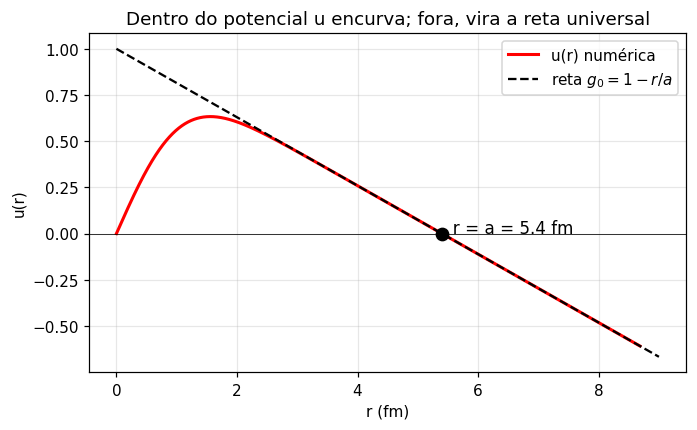

In [2]:
pot = Gaussiano(1.9102, 0.6754)          # parâmetros da Tabela 3 do artigo
res = espalhamento.calcular(pot, dr=1e-3)
print(f'a  = {res.a:.4f} fm   (artigo: 5.40)')
print(f'r0 = {res.r0:.4f} fm  (artigo: 1.70)')
print(f'nós = {res.nos}  (1 nó <-> existe estado ligado: o dêuteron!)')

r = res.r
fig, ax = plt.subplots(figsize=(7, 4))
m = r <= 9
ax.plot(r[m], res.u[m], 'r-', lw=2, label='u(r) numérica')
rr = np.linspace(0, 9, 200)
ax.plot(rr, 1 - rr/res.a, 'k--', label='reta $g_0 = 1 - r/a$')
ax.plot([res.a], [0], 'ko', ms=8)
ax.annotate('  r = a = 5.4 fm', (res.a, 0), fontsize=11)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('r (fm)'); ax.set_ylabel('u(r)'); ax.legend()
ax.set_title('Dentro do potencial u encurva; fora, vira a reta universal')
plt.show()

**O que olhar:** a curva vermelha "gruda" na reta tracejada assim que
o potencial acaba (~3 fm). Todo o efeito do potencial ficou codificado no
intercepto $a$. É por isso que $a$ é chamado de "tamanho efetivo" do alvo.

## 2. Os três regimes físicos

Mesmo potencial (mPT), três profundidades — veja o intercepto se mover:

| regime | $a$ | significado |
|---|---|---|
| n–n | $-18{,}5$ fm | quase liga, mas não liga (0 nós) |
| unitário | $\pm\infty$ | limiar exato — a reta fica horizontal |
| dêuteron | $+5{,}4$ fm | estado ligado raso (1 nó) |

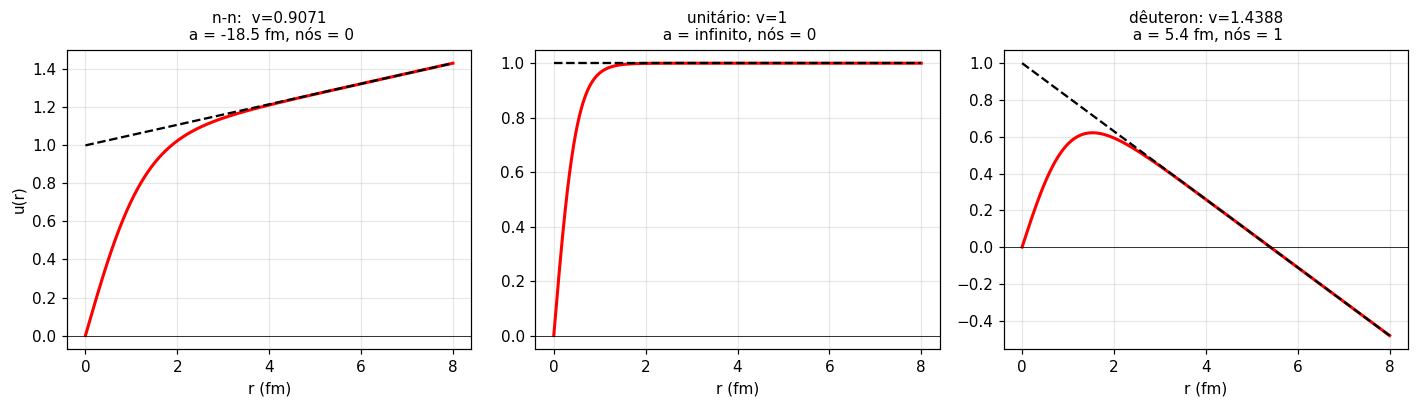

In [3]:
casos = [('n-n:  v=0.9071', PoschlTeller(0.9071, 0.7991)),
         ('unitário: v=1', PoschlTeller(1.0, 2.0)),
         ('dêuteron: v=1.4388', PoschlTeller(1.4388, 0.8631))]
fig, eixos = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (nome, pot) in zip(eixos, casos):
    res = espalhamento.calcular(pot, dr=1e-3)
    m = res.r <= 8
    ax.plot(res.r[m], res.u[m], 'r-', lw=2)
    rr = np.linspace(0, 8, 100)
    g0 = np.ones_like(rr) if abs(res.a) > 1e4 else 1 - rr/res.a
    ax.plot(rr, g0, 'k--')
    a_txt = 'infinito' if abs(res.a) > 1e4 else f'{res.a:.1f} fm'
    ax.set_title(f'{nome}\n a = {a_txt}, nós = {res.nos}', fontsize=10)
    ax.axhline(0, color='k', lw=0.5); ax.set_xlabel('r (fm)')
eixos[0].set_ylabel('u(r)')
plt.tight_layout(); plt.show()

**O que olhar:** no caso unitário a reta é horizontal ($1 - r/\infty = 1$):
o sistema está exatamente no limiar de formar um estado ligado. Esse é o
regime do efeito Efimov — o do seu mestrado.

## 3. Universalidade: 4 potenciais, mesma física

Agora o ponto principal do artigo. Poço, mPT, gaussiano e Lennard-Jones têm
formas completamente diferentes — mas sintonizados para os mesmos $(a, r_0)$,
**fora do alcance são indistinguíveis**:

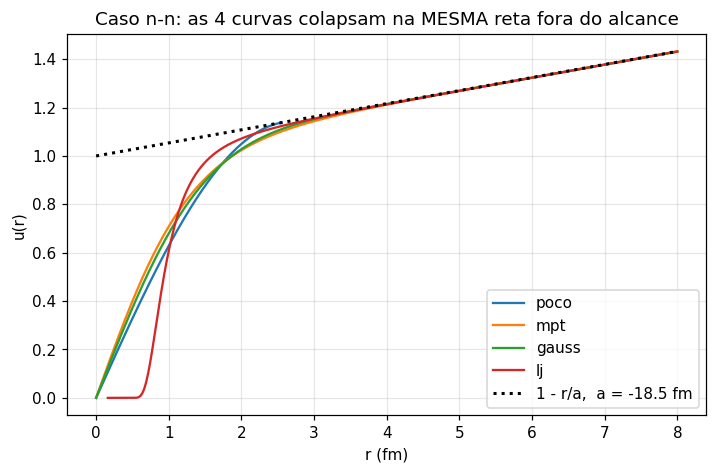

In [4]:
from src.tabelas_artigo import TABELA3, TABELA4
from src.potenciais import FABRICAS
fig, ax = plt.subplots(figsize=(7.5, 4.5))
cores = {'poco':'tab:blue','mpt':'tab:orange','gauss':'tab:green','lj':'tab:red'}
for pot_nome in ('poco','mpt','gauss','lj'):
    tab = TABELA4 if pot_nome=='lj' else TABELA3
    p = tab[('nn', pot_nome)]
    res = espalhamento.calcular(FABRICAS[pot_nome](p['p1'], p['p2']), dr=2e-3)
    m = res.r <= 8
    ax.plot(res.r[m], res.u[m], color=cores[pot_nome], label=pot_nome)
rr = np.linspace(0, 8, 100)
ax.plot(rr, 1 - rr/(-18.5), 'k:', lw=2, label='1 - r/a,  a = -18.5 fm')
ax.set_xlabel('r (fm)'); ax.set_ylabel('u(r)'); ax.legend()
ax.set_title('Caso n-n: as 4 curvas colapsam na MESMA reta fora do alcance')
plt.show()

**O que olhar:** dentro de ~2 fm cada potencial faz o que quer (o LJ até
zera u no caroço repulsivo!). Fora, ninguém consegue dizer qual é qual.
A física de baixa energia só enxerga $(a, r_0)$ — *independência da forma*.

## 4. De $(a, r_0)$ à energia do dêuteron

Com só esses dois números + a massa reduzida, a expansão de alcance efetivo
prevê a energia do estado ligado (Eqs. 93 e 95 do artigo):

In [5]:
from src import constantes as cte
h22m = cte.hbar2_over_2mr_MeV_fm2(cte.M_R_NP_MEV)
a, r0 = 5.4112, 1.7436                      # medidos (Hackenburg 2006)
print(f'alcance zero  : E = {analitico.energia_zr(a, h22m):+.3f} MeV  (64% do real)')
print(f'alcance finito: E = {analitico.energia_fr(a, r0, h22m):+.3f} MeV')
print( 'experimento   : E = -2.224 MeV')

alcance zero  : E = -1.416 MeV  (64% do real)
alcance finito: E = -2.223 MeV
experimento   : E = -2.224 MeV


Dois números de espalhamento reproduzem a energia de ligação do dêuteron
com 0,05% de erro. É a demonstração mais concreta de por que $a$ e $r_0$
"bastam" em baixa energia.

## 5. A divergência de $a$ = nascimento de um estado ligado

Varremos a profundidade $v$ do gaussiano e marcamos o limiar analítico do
Jeszenszki et al. (nosso benchmark [34]):

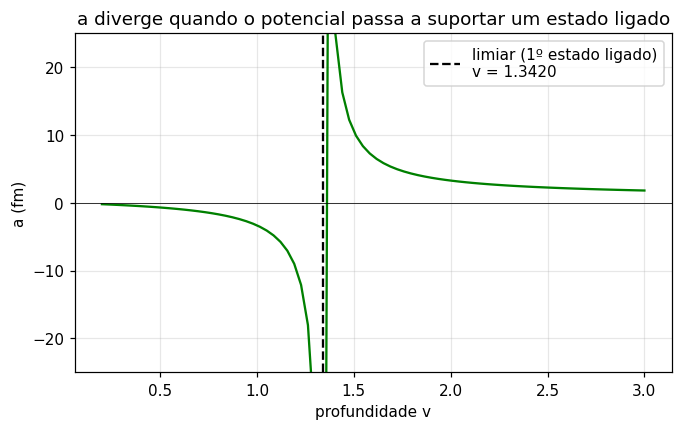

In [6]:
vs = np.linspace(0.2, 3.0, 80)
avals = [espalhamento.calcular(Gaussiano(v, 1.0), dr=2e-3).a for v in vs]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(vs, avals, 'g-')
ax.axvline(1.3420, color='k', ls='--', label='limiar (1º estado ligado)\nv = 1.3420')
ax.set_ylim(-25, 25); ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('profundidade v'); ax.set_ylabel('a (fm)'); ax.legend()
ax.set_title('a diverge quando o potencial passa a suportar um estado ligado')
plt.show()

**O que olhar:** vindo da esquerda, $a \to -\infty$; do outro lado do
limiar, $a$ volta de $+\infty$. Ajustar um potencial "na unitariedade" =
parar exatamente em cima dessa parede.

## Onde continuar

- `GUIA.md` — física + as 7 pegadinhas numéricas
- `GUIA_REPOSITORIO.md` — mapa dos arquivos + o que estudar a fundo
- `interativo/laboratorio.py` — mexa nos sliders e veja tudo isso ao vivo
- `python -m pytest tests/ -q` — os 17 testes que protegem tudo